In [64]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from sklearn.preprocessing import QuantileTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr
import seaborn as sns

In [52]:
fish_ages = [4,6,8]

sensory_feature_names = ["initial_L_0","initial_L_1","initial_L_2","initial_m_0","initial_m_1","initial_m_2","cosine_avoidance_0","cosine_avoidance_1","cosine_avoidance_2", "distance_to_wall"]
motor_feature_names = ["T_burst","cum_delta_theta","delta_L_0","delta_L_1","delta_L_2","delta_m_0","delta_m_1","delta_m_2","reaction_time_0","reaction_time_1","reaction_time_2", "delta_v"]


# laod optimal gmms
results_path = '../../Results/optimal_sensory_motor_clusters.pkl'

with open(results_path, 'rb') as f:
    optimal_gmm_results = pickle.load(f)
    optimal_gmms_sensory = optimal_gmm_results['optimal_gmms_sensory']
    optimal_gmms_motor = optimal_gmm_results['optimal_gmms_motor']
    feature_dfs_with_labels = optimal_gmm_results['feature_dfs_with_labels']


In [60]:
agewise_motor_cluster_names = [
    ['diffusion', 'cohesion', 'maintain heading', 'alignment'],
    ['diffusion', 'alignment', 'cohesion', 'maintain heading'],
    ['diffusion', 'cohesion', 'maintain heading', 'alignment']
]
agewise_sensory_cluster_names= [
    ['alone', 'triad', 'pair'],
    ['school\n(back)', 'triad\n(front)', 'school\n(front)', 'triad\n(back)', 'pair', 'alone'],
    ['school\n(middle)', 'school\n(back)', 'school\n(front)', 'pair']

]

colors_motor =np.array([[0.4       , 0.4       , 0.4       , 1.        ],
       [0.83921569, 0.15294118, 0.15686275, 1.        ],
       [0.89019608, 0.46666667, 0.76078431, 1.        ],
       [0.09019608, 0.74509804, 0.81176471, 1.        ]])

colors_sensory = np.array([[0.58039216, 0.40392157, 0.74117647, 1.        ],
                           [0.12156863, 0.46666667, 0.70588235, 1.        ],
                          [0.17254902, 0.62745098, 0.17254902, 1.        ],
       [0.54117647, 0.08235294, 0.       , 1.        ],
       [0.7372549 , 0.74117647, 0.13333333, 1.        ],
       [0.61960784, 0.85490196, 0.89803922, 1.        ]])

# cluster_order[i][l] is position we want to give the l^th cluster in the reordering for age i
sensory_clusters_reorder_mapping = [
    [2,0,1],
    [1,2,0,3,4,5],
    [1,2,0,3]
]

motor_clusters_reorder_mapping=[
    [0,3,2,1],
    [0,1,3,2],
    [0,3,2,1],
]

In [35]:
ylabels = {
    "initial_L" : "$L_i$ (mm)",
    "initial_m" : "$m_i$",
    "cosine_avoidance" : r"$\mathrm{cos}\psi_i$",
    "distance_to_wall" : r"$\mathrm{d_{wall}}$ (mm)",
    "cum_delta_theta" : r"$\Delta\theta$",
    "delta_L" : r"$\Delta L_i$ (mm)",
    "delta_m" : r"$\Delta m_i$",
    "reaction_time" : r"$\mathrm{T^i_{react}}$ (s)",
    "delta_v" : r"$\Delta v$ (mm/s)",
    "T_burst" : r"$\mathrm{T_{burst}}$ (s)"
}

ylims = {
    "distance_to_wall": (0, 120),
    "initial_L": (0, 150),
    "initial_m": (0, 1.05),
    "cosine_avoidance": (-1, 1),
    "avoidance_angle": (0, np.pi),
    "delta_L": (-5, 5),
    "delta_m": (-0.4, 0.4),
    "reaction_time": (0, 0.5),
    "cum_delta_theta": (0,np.pi/2),
    "delta_v": (0, 55),
    "T_burst": (0, 0.4)

        
}

yticks = {
    "distance_to_wall": [0, 50, 100],
    "initial_L": [0, 50, 100, 150],
    "initial_m": [0, 0.5, 1],
    "cosine_avoidance": [-1, 0, 1],
    "avoidance_angle": [0, np.pi/2, np.pi],
    "delta_L": [-5, 0, 5],
    "delta_m": [-0.4,0, 0.4],
    "reaction_time": [0, 0.25,0.5],
    "cum_delta_theta": [0,np.pi/4, np.pi/2],
    "delta_v": [0, 25, 50],
    "T_burst": [0, 0.2, 0.4]
}

ytickslabels = {
    "distance_to_wall": [0, 50, 100],
    "initial_L": [0, 50, 100, 150],
    "initial_m": [0, 0.5, 1],
    "cosine_avoidance": [-1, 0, 1],
    "avoidance_angle": ["0", r"$\pi/2$", r"$\pi$"],
    "delta_L": [-5, 0, 5],
    "delta_m": [-0.4,0, 0.4],
    "reaction_time": [0, 0.25,0.5],
    "cum_delta_theta": ["0",r"$\pi/4$", r"$\pi/2$"],
    "delta_v": [0, 25, 50],
    "T_burst": [0, 0.2, 0.4]
}

In [36]:
def get_2d_projection(featureDF, labels, scaling=True):
    
    if scaling:
        scaler = QuantileTransformer(output_distribution='normal')
        featureDF = scaler.fit_transform(featureDF)

    lda = LDA(n_components=2)
    lda.fit(featureDF, labels)
    u1 = lda.scalings_[:,0]  
    u2 = lda.scalings_[:,1]
    # print angle between u1 and u2
    angle = np.arccos(np.dot(u1, u2) / (np.linalg.norm(u1) * np.linalg.norm(u2)))
    print(f"Angle between LD1 and LD2: {np.degrees(angle):.2f} degrees")
    # orthogonalize u2 with respect to u1
    u1 = u1 / np.linalg.norm(u1)
    u2 = u2 - (u2 @ u1) * u1
    u2 = u2 / np.linalg.norm(u2)

    featureDF_lda = featureDF @ np.vstack((u1, u2)).T
    featureDF_lda_df = pd.DataFrame(featureDF_lda, columns=['LD1', 'LD2'])
    return featureDF_lda_df

Angle between LD1 and LD2: 127.58 degrees
Angle between LD1 and LD2: 78.34 degrees
Angle between LD1 and LD2: 71.58 degrees


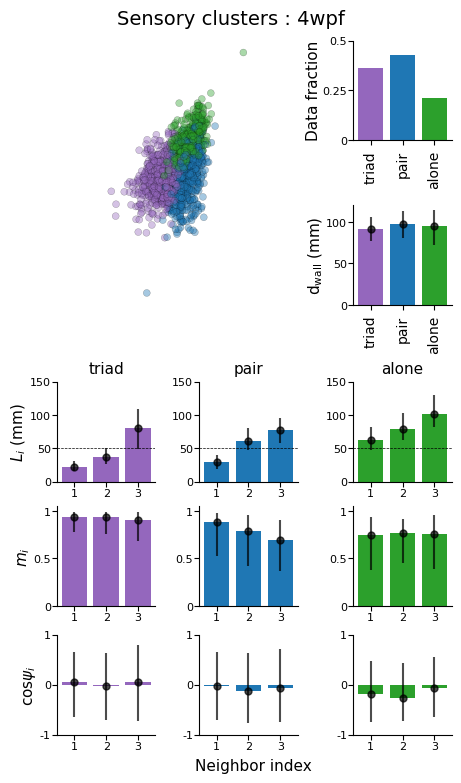

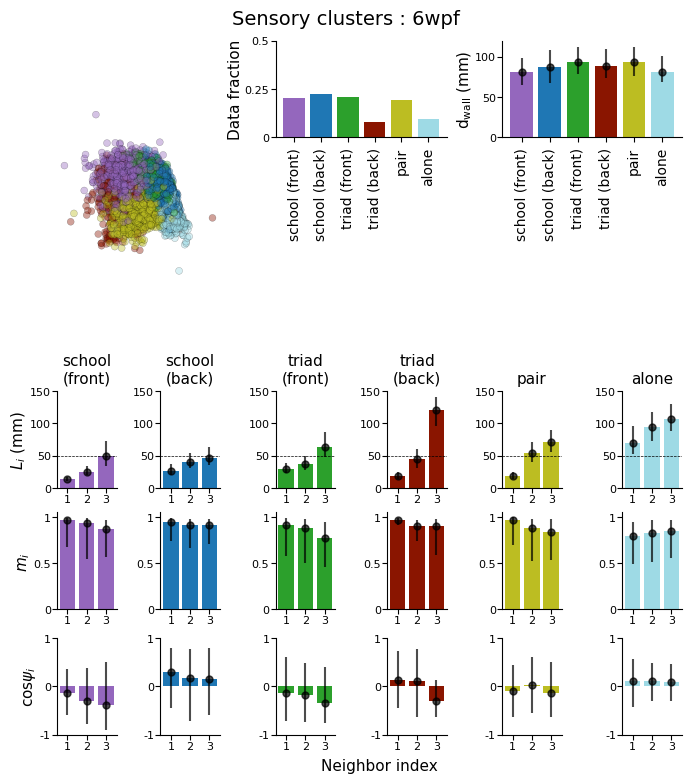

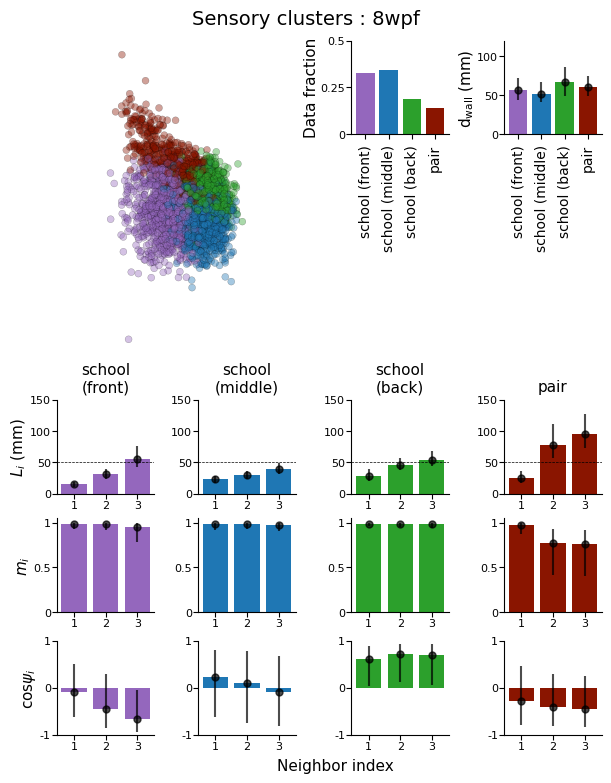

In [57]:
# sensory features with 2d projection
features_to_plot_separately = ["initial_L", "initial_m", 
                               "cosine_avoidance", 
                              ]
features_to_plot_together = ["distance_to_wall"]

suptitle_size = 14
cluster_names_size = 10
title_size = 11
labelsize = 11
tick_size = 8

rasterized = True
for i in range(3):
    featureDF = feature_dfs_with_labels[f'{fish_ages[i]}wpf'][sensory_feature_names].copy()
    labels = feature_dfs_with_labels[f'{fish_ages[i]}wpf']['sensory_cluster'].values
    # reorder clusters
    labels = np.array([sensory_clusters_reorder_mapping[i][l] for l in labels])
    # reorder cluster names
    cluster_names = agewise_sensory_cluster_names[i]
    n_clusters = len(cluster_names)
    cluster_names_reordered = [None] * n_clusters
    for ii, target_pos in enumerate(sensory_clusters_reorder_mapping[i]):
        cluster_names_reordered[target_pos] = cluster_names[ii]
  
    n_feature_to_plot_separately = len(features_to_plot_separately)
    n_features_to_plot_together = len(features_to_plot_together)
    
    colors = colors_sensory
    nrows = 2 + n_feature_to_plot_separately
    ncols = n_clusters
    fig = plt.figure(figsize=(min(6.8,1.5*ncols), 1.5*nrows),constrained_layout=True)
    gs = gridspec.GridSpec(nrows, ncols, figure=fig)

    ############################
    #### scatter plot to take up one subplot only
    ############################
    ax_scatter = fig.add_subplot(gs[0:2, 0:2])
    features_lda = get_2d_projection(featureDF, labels, scaling=True)
    ax_scatter.scatter(features_lda['LD1'], features_lda['LD2'], c=colors[labels], alpha=0.4, s=25, edgecolor='k', linewidth=0.25, rasterized=rasterized)
    ax_scatter.set_aspect('equal', 'box')
    ax_scatter.axis('off')
    cluster_names_as_ticks = [name.replace('\n', ' ') for name in cluster_names_reordered]

    ########
    ## Number of data points
    #######
    featureDF['labels'] = labels
    cluster_counts = featureDF['labels'].value_counts().sort_index()
    cluster_fractions = cluster_counts / cluster_counts.sum()
    if i==1:
        ax_fractions = fig.add_subplot(gs[0:1, 2:4])
    else:
        ax_fractions  = fig.add_subplot(gs[0:1, 2:3])
    ax_fractions.bar(range(n_clusters), cluster_fractions, color=colors[:n_clusters])
    ax_fractions.set_xticks(range(n_clusters))
    ax_fractions.set_xticklabels(cluster_names_as_ticks, rotation=90, ha='center', fontsize=cluster_names_size)
    ax_fractions.set_ylabel("Data fraction", fontsize=labelsize,labelpad=1)
    ax_fractions.set_ylim(0, 0.5)
    ax_fractions.set_yticks([0, 0.25, 0.5], ['0', '0.25', '0.5'])
    ax_fractions.tick_params(axis='y', which='major', labelsize=tick_size, pad=1)
    ax_fractions.spines['top'].set_visible(False)
    ax_fractions.spines['right'].set_visible(False)

    ############################
    #### distance to wall
    ############################
    means = featureDF.groupby('labels').quantile(0.5)
    lower_bound = featureDF.groupby('labels').quantile(0.25)
    upper_bound = featureDF.groupby('labels').quantile(0.75)

    if i==2:
        ax_dwall = fig.add_subplot(gs[0:1, 3:4])
    elif i==1:
        ax_dwall = fig.add_subplot(gs[0:1, 4:6])
    else:
        ax_dwall = fig.add_subplot(gs[1:2, 2:3])
    feature = 'distance_to_wall'
    ax_dwall.bar(range(n_clusters), means[feature], color=colors[:n_clusters])
    ax_dwall.errorbar(range(n_clusters), means[feature], yerr=[means[feature]-lower_bound[feature], upper_bound[feature]-means[feature]], color='k', marker='o',linestyle='None', alpha=0.7, markersize=5)
    ax_dwall.set_xticks(range(n_clusters))
    ax_dwall.set_xticklabels(cluster_names_as_ticks, rotation=90, ha='center', fontsize=cluster_names_size)
    ylabel = ax_dwall.set_ylabel(ylabels[feature], fontsize=labelsize,labelpad=1)
    #ylabel.set_position((ylabel.get_position()[0]-0.1, ylabel.get_position()[1]-0.1))
    ax_dwall.set_ylim(ylims[feature])
    ax_dwall.set_yticks(yticks[feature],ytickslabels[feature])
    ax_dwall.tick_params(axis='y', which='major', labelsize=tick_size, pad=1)
    # turn off top and right spines
    ax_dwall.spines['top'].set_visible(False)
    ax_dwall.spines['right'].set_visible(False) 

    ####### feature plots (separately) below 
    ax_features_separately = [[fig.add_subplot(gs[2+n, i:i+1]) for i in range(0, n_clusters)] for n in range(n_feature_to_plot_separately)]
    for n, feature in enumerate(features_to_plot_separately):
        feature_names = [f'{feature}_{i}' for i in range(3)]
        for j in range(n_clusters):
            ax_features_separately[n][j].bar(range(3), means.loc[j, feature_names], color=colors[j])
            ax_features_separately[n][j].errorbar(range(3), means.loc[j, feature_names], yerr=[means.loc[j, feature_names]-lower_bound.loc[j, feature_names], upper_bound.loc[j, feature_names]-means.loc[j, feature_names]], color='k', marker='o',linestyle='None', alpha=0.7, markersize=5)
            ax_features_separately[n][j].set_xticks(range(3), range(1,4))
            ax_features_separately[n][j].set_ylim(ylims[feature])
            ax_features_separately[n][j].set_yticks(yticks[feature],ytickslabels[feature])
            if j == 0:
                ax_features_separately[n][j].set_ylabel(ylabels[feature], fontsize=labelsize,labelpad=1)

            if n == 0:
                ax_features_separately[n][j].set_title(cluster_names_reordered[j], fontsize=title_size)

            ax_features_separately[n][j].tick_params(axis='both', which='major', labelsize=tick_size, pad=1)
            if feature == 'initial_L':
                ax_features_separately[n][j].axhline(50, color='k', linestyle='--', linewidth=0.5)

            if feature == 'avoidance_angle':
                ax_features_separately[n][j].axhline(np.pi/2, color='k', linestyle='--', linewidth=0.5)
            # turn off top and right spines
            ax_features_separately[n][j].spines['top'].set_visible(False)
            ax_features_separately[n][j].spines['right'].set_visible(False)
    # add text for a common x label
    fig.text(0.55, -0.02, 'Neighbor index', ha='center', fontsize=labelsize)
    fig.suptitle(f"Sensory clusters : {fish_ages[i]}wpf", fontsize=suptitle_size)








Angle between LD1 and LD2: 91.68 degrees
Angle between LD1 and LD2: 82.69 degrees
Angle between LD1 and LD2: 85.68 degrees


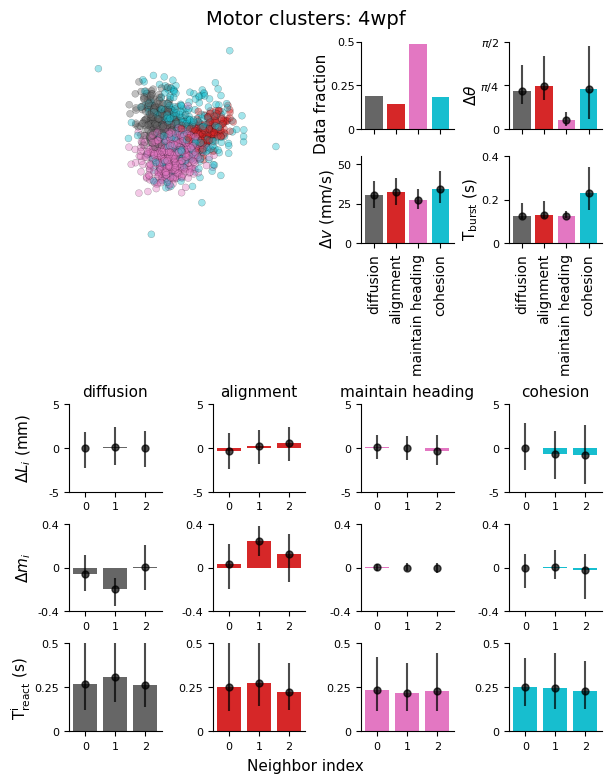

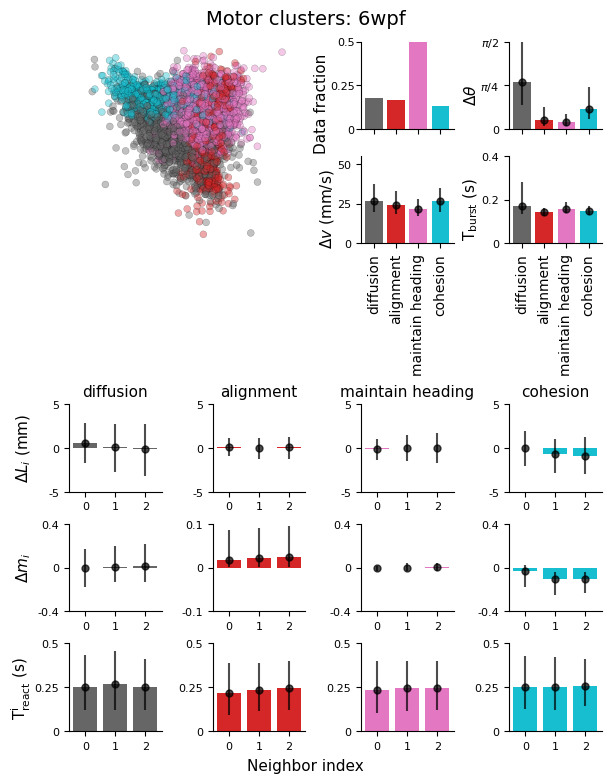

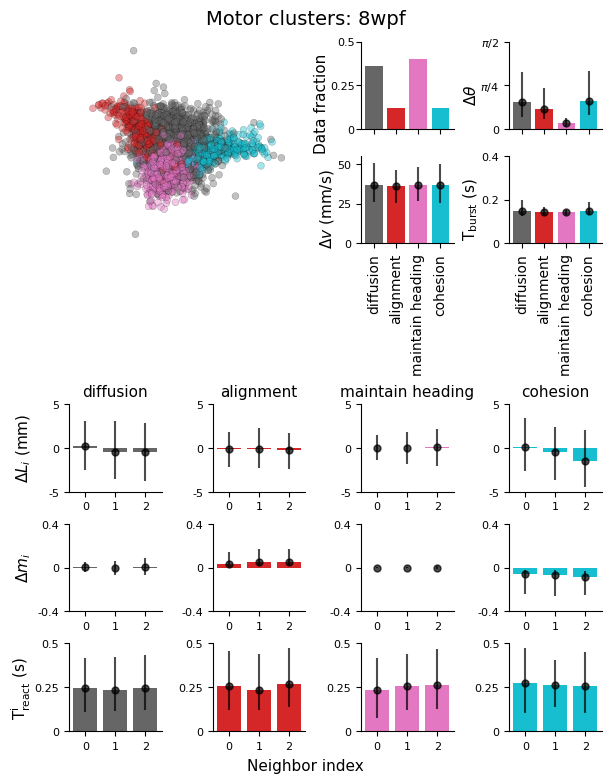

In [61]:
# motor features with 2d projection
features_to_plot_separately = ["delta_L", "delta_m", 
                               "reaction_time"
                              ]
features_to_plot_together = ["cum_delta_theta", "delta_v", "T_burst"]

suptitle_size = 14
cluster_names_size = 10
title_size = 11
labelsize = 11
tick_size = 8

rasterized = True
for i in range(3):
    featureDF = feature_dfs_with_labels[f'{fish_ages[i]}wpf'][motor_feature_names].copy()
    labels = feature_dfs_with_labels[f'{fish_ages[i]}wpf']['motor_cluster']
    # reorder clusters
    labels = np.array([motor_clusters_reorder_mapping[i][l] for l in labels])
    cluster_names = agewise_motor_cluster_names[i]
    n_clusters = len(cluster_names)
    cluster_names_reordered = [None] * n_clusters
    for ii, target_pos in enumerate(motor_clusters_reorder_mapping[i]):
        cluster_names_reordered[target_pos] = cluster_names[ii]
    cluster_names = cluster_names_reordered

    colors = colors_motor

    n_clusters = len(cluster_names)
    n_feature_to_plot_separately = len(features_to_plot_separately)
    n_features_to_plot_together = len(features_to_plot_together)
    
    nrows = 2 + n_feature_to_plot_separately
    ncols = n_clusters
    fig = plt.figure(figsize=(1.5*ncols, 1.5*nrows),constrained_layout=True)
    gs = gridspec.GridSpec(nrows, ncols, figure=fig)

    ############################
    #### scatter plot to take up first two rows and columns
    ############################
    ax_scatter = fig.add_subplot(gs[0:2, 0:2])
    features_lda = get_2d_projection(featureDF, labels, scaling=True)
    ax_scatter.scatter(features_lda['LD1'], features_lda['LD2'], c=colors[labels], alpha=0.4, s=25, edgecolor='k', linewidth=0.25, rasterized=rasterized)
    ax_scatter.set_aspect('equal')
    ax_scatter.axis('off')


    ############################
    #### features
    ############################
    featureDF['labels'] = labels
    means = featureDF.groupby('labels').quantile(0.5)
    lower_bound = featureDF.groupby('labels').quantile(0.25)
    upper_bound = featureDF.groupby('labels').quantile(0.75)

    ####### feature plots (together) next to scatter
    ax_features_together = [[fig.add_subplot(gs[r:r+1, i]) for i in range(2, n_clusters)] for r in range(2)] # this is 4 plots in 2 rows
    ax_features_together = [item for sublist in ax_features_together for item in sublist]  # flatten list

    # first plot fraction of data points in each cluster
    ax_fractions = ax_features_together[0]
    cluster_counts = featureDF['labels'].value_counts().sort_index()
    cluster_fractions = cluster_counts / cluster_counts.sum()
    ax_fractions.bar(range(n_clusters), cluster_fractions, color=colors[:n_clusters])
    ax_fractions.set_xticks(range(n_clusters),[])
    #ax_fractions.set_xticklabels(cluster_names, rotation=90, ha='right', fontsize=cluster_names_size)
    ylabel = ax_fractions.set_ylabel("Data fraction", fontsize=labelsize,labelpad=1)
    ylabel.set_position((ylabel.get_position()[0], ylabel.get_position()[1]-0.2))
    ax_fractions.set_ylim(0, 0.5)
    ax_fractions.set_yticks([0, 0.25, 0.5], ['0', '0.25', '0.5'], fontsize=tick_size)
    ax_fractions.tick_params(axis='both', which='major', pad=1)
    ax_fractions.spines['top'].set_visible(False)
    ax_fractions.spines['right'].set_visible(False)

    # next plots are features
    for j, feature in enumerate(features_to_plot_together):
        ax_features_together[j+1].bar(range(n_clusters), means[feature], color=colors[:n_clusters])
        ax_features_together[j+1].errorbar(range(n_clusters), means[feature], yerr=[means[feature]-lower_bound[feature], upper_bound[feature]-means[feature]], color='k', marker='o',linestyle='None', alpha=0.7, markersize=5)
        ax_features_together[j+1].set_xticks(range(n_clusters),[])
        if j>0:
            ax_features_together[j+1].set_xticklabels(cluster_names, rotation=90, ha='center', fontsize=cluster_names_size)
        ylabel = ax_features_together[j+1].set_ylabel(ylabels[feature], fontsize=labelsize,labelpad=1)
        ylabel.set_position((ylabel.get_position()[0], ylabel.get_position()[1]-0.1))
        ax_features_together[j+1].set_ylim(ylims[feature])
        ax_features_together[j+1].set_yticks(yticks[feature],ytickslabels[feature],fontsize=tick_size)
        # turn off top and right spines
        ax_features_together[j+1].spines['top'].set_visible(False)
        ax_features_together[j+1].spines['right'].set_visible(False)

    ####### feature plots (separately) below scatter plot
    ax_features_separately = [[fig.add_subplot(gs[2+n, i:i+1]) for i in range(0, n_clusters)] for n in range(n_feature_to_plot_separately)]
    for n, feature in enumerate(features_to_plot_separately):
        feature_names = [f'{feature}_{i}' for i in range(3)]
        for j in range(n_clusters):
            ax_features_separately[n][j].bar(range(3), means.loc[j, feature_names], color=colors[j])
            ax_features_separately[n][j].errorbar(range(3), means.loc[j, feature_names], yerr=[means.loc[j, feature_names]-lower_bound.loc[j, feature_names], upper_bound.loc[j, feature_names]-means.loc[j, feature_names]], color='k', marker='o',linestyle='None', alpha=0.7, markersize=5)
            ax_features_separately[n][j].set_xticks(range(3), range(3), fontsize=tick_size)
            if j == 0:
                ax_features_separately[n][j].set_ylabel(ylabels[feature], fontsize=labelsize,labelpad=1)
            if n == 0:
                ax_features_separately[n][j].set_title(cluster_names[j], fontsize=title_size)
            ax_features_separately[n][j].set_ylim(ylims[feature])
            ax_features_separately[n][j].set_yticks(yticks[feature], ytickslabels[feature], fontsize=tick_size)

            if feature == 'initial_L':
                ax_features_separately[n][j].axhline(50, color='k', linestyle='--', linewidth=1)

            if feature == 'avoidance_angle':
                ax_features_separately[n][j].axhline(np.pi/2, color='k', linestyle='--', linewidth=1)
            
            if i == 1 and j==1 and feature == 'delta_m':
                ax_features_separately[n][j].set_ylim([-0.1, 0.1])
                ax_features_separately[n][j].set_yticks([-0.1, 0, 0.1], ['-0.1', '0', '0.1'], fontsize=tick_size)

            # turn off top and right spines
            ax_features_separately[n][j].spines['top'].set_visible(False)
            ax_features_separately[n][j].spines['right'].set_visible(False)
    fig.align_ylabels(ax_features_separately)
    fig.text(0.5, -0.02, 'Neighbor index', ha='center', fontsize=labelsize)
    fig.suptitle(f"Motor clusters: {fish_ages[i]}wpf", fontsize=suptitle_size)



# Sensorimotor transformation 
Pearson correlations between sensory & motor cluster probabilities

In [62]:
# calculate cluster probabilities
sensory_cluster_probs = []
motor_cluster_probs = []

scaler = QuantileTransformer(output_distribution='normal')

for i,age in enumerate(fish_ages):
    features = scaler.fit_transform(feature_dfs_with_labels[f'{age}wpf'][sensory_feature_names])
    sensory_cluster_probs.append(optimal_gmms_sensory[i].predict_proba(features))

    features = scaler.fit_transform(feature_dfs_with_labels[f'{age}wpf'][motor_feature_names])
    motor_cluster_probs.append(optimal_gmms_motor[i].predict_proba(features))

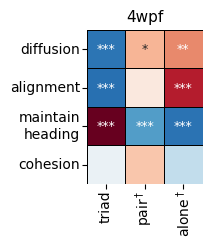

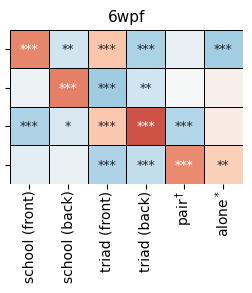

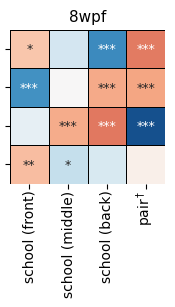

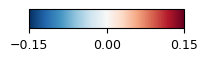

In [65]:
lims = [0.15,0.15,0.15]

cluster_names_size = 10
title_size = 11
labelsize = 11
tick_size = 9

agewise_motor_cluster_names_renamed = [
    ['diffusion', 'cohesion', 'maintain\nheading', 'alignment'],
    ['diffusion', 'alignment', 'cohesion', 'maintain\nheading'],
    ['diffusion', 'cohesion', 'maintain\nheading', 'alignment']
]

agewise_sensory_cluster_names_renamed = [
    [r'alone$^\dagger$', 'triad', r'pair$^\dagger$'],
    ['school (back)', 'triad (front)', 'school (front)', 'triad (back)', r'pair$^\dagger$', 'alone$^*$'],
    ['school (middle)', 'school (back)', 'school (front)', r'pair$^\dagger$']

]


for i in range(3):
    sensory_cluster_names = agewise_sensory_cluster_names_renamed[i]
    sensory_probs = sensory_cluster_probs[i]
    # reorder sensory clusters
    sensory_cluster_order = sensory_clusters_reorder_mapping[i]
    sensory_cluster_names_reordered = [None] * len(sensory_cluster_names)
    for ii, target_pos in enumerate(sensory_cluster_order):
        sensory_cluster_names_reordered[target_pos] = sensory_cluster_names[ii]
    sensory_probs_reordered = np.zeros(sensory_probs.shape)
    for ii, target_pos in enumerate(sensory_cluster_order):
        sensory_probs_reordered[:, target_pos] = sensory_probs[:, ii]

    motor_cluster_names = agewise_motor_cluster_names_renamed[i]
    motor_probs = motor_cluster_probs[i]
    # reorder motor clusters
    motor_cluster_order = motor_clusters_reorder_mapping[i]
    motor_cluster_names_reordered = [None] * len(motor_cluster_names)
    for ii, target_pos in enumerate(motor_cluster_order):
        motor_cluster_names_reordered[target_pos] = motor_cluster_names[ii]
    motor_probs_reordered = np.zeros(motor_probs.shape)
    for ii, target_pos in enumerate(motor_cluster_order):
        motor_probs_reordered[:, target_pos] = motor_probs[:, ii]
    
    n_sensory_components = len(sensory_cluster_names)
    n_motor_components = len(motor_cluster_names)

    # Correlation
    correlation_matrix_pearson = np.zeros((n_sensory_components, n_motor_components))
    p_values_pearson = np.zeros((n_sensory_components, n_motor_components))
    for s in range(n_sensory_components):
        for m in range(n_motor_components):
            # Pearson correlation
            corr, p_val = pearsonr(sensory_probs_reordered[:,s], motor_probs_reordered[:,m]) 
            correlation_matrix_pearson[s, m] = corr
            p_values_pearson[s, m] = p_val
    
    # calculate transpose
    correlation_matrix_pearson = correlation_matrix_pearson.T
    p_values_pearson = p_values_pearson.T

    fig, ax = plt.subplots(figsize=(0.5*n_sensory_components,0.5*n_motor_components))
    # plot pearson correlation matrix
    # find stars for p-values
    def pval_to_stars(p):
        if p < 0.001:
            return '***'
        elif p < 0.01:
            return '**'
        elif p < 0.05:
            return '*'
        else:
            return ''

    annot_text = np.array([["{}".format(pval_to_stars(p_values_pearson[i,j])) for j in range(n_sensory_components)] for i in range(n_motor_components)])
    map = sns.heatmap(correlation_matrix_pearson, annot=annot_text, fmt='', cmap='RdBu_r', ax=ax, linewidths=0.5, linecolor='black',vmin=-lims[i], vmax=lims[i], annot_kws={"size": tick_size},cbar=False)
    if i==0:
        ax.set_yticks(0.5+np.arange(n_motor_components),motor_cluster_names_reordered, rotation=0, fontsize=cluster_names_size)
    else:
        ax.set_yticks(0.5+np.arange(n_motor_components),[])
    ax.set_xticks(0.5+np.arange(n_sensory_components),sensory_cluster_names_reordered,rotation=90, fontsize=cluster_names_size)
    ax.set_title(f"{fish_ages[i]}wpf", fontsize=title_size)
    ax.tick_params(axis='both', which='major', pad=1)

# colorbar on separate figure
fig_cb, ax_cb = plt.subplots(figsize=(2,0.25))
norm = plt.Normalize(vmin=-0.15, vmax=0.15)
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm)
sm.set_array([])
cbar = fig_cb.colorbar(sm, cax=ax_cb, orientation='horizontal')
#cbar.set_label('Pearson correlation of', fontsize=labelsize)
cbar.set_ticks([-0.15, 0, 0.15])
cbar.ax.tick_params(labelsize=tick_size)

